# Step 5: ST-DBSCAN clustering

Goal: group earthquakes that are close in **both space and time**, to find
aftershock sequences and swarms.

Input: `data/processed/quakes_clean.csv`, `results/known_events.csv` (Step 4).
Output: `results/clusters_summary.csv`, `results/step5_event_clusters.csv`
(cluster of every event), `results/step5_param_search.csv`,
`results/step5_facts.csv`, figures `figures/step5_*.png`.

**Why our own implementation:** the `st-dbscan` package does not install on
Python 3.12+ (its setup script needs `pkg_resources`). ST-DBSCAN (Birant & Kut,
2007) is DBSCAN with a different neighbourhood: two earthquakes are neighbours
only if they are within `eps1` km on the Earth's surface **and** within `eps2`
days. We build exactly that neighbourhood graph and give it to scikit-learn's
`DBSCAN(metric="precomputed")`, so the core / border / noise logic is the
standard, tested one. (The optional `delta_eps` density check of the paper is
not used.)

In [1]:
import sys
sys.path.append("../scripts")
from config import *

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.sparse import csr_matrix
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

# same look as Steps 3-4
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
NOISE = "#c9c8c3"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10,
})
thousands = FuncFormatter(lambda v, _: f"{v:,.0f}")
for folder in (FIGURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=FIG_DPI, bbox_inches="tight")
    print("saved", FIGURES_DIR / name)

facts = []
def fact(item, value):
    facts.append({"item": item, "value": value})
    print(f"{item}: {value}")

## 1. Load the data

In [2]:
df = pd.read_csv(CLEAN_FILE, dtype={"id": str})
df["time"] = pd.to_datetime(df["time"], utc=True, format="ISO8601")
df = df.sort_values("time").reset_index(drop=True)
n = len(df)

EARTH_KM = 6371.0088
lat, lon = np.radians(df["latitude"].to_numpy()), np.radians(df["longitude"].to_numpy())
# points on a sphere of the Earth's radius (km), for fast neighbour search
xyz = np.c_[np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)] * EARTH_KM
# days since 2000-01-01 (not astype("int64"): its unit depends on the pandas version)
days = (df["time"] - pd.Timestamp("2000-01-01", tz="UTC")).dt.total_seconds().to_numpy() / 86400

def haversine_km(i, j):
    a = np.sin((lat[j] - lat[i]) / 2) ** 2 + np.cos(lat[i]) * np.cos(lat[j]) * np.sin((lon[j] - lon[i]) / 2) ** 2
    return 2 * EARTH_KM * np.arcsin(np.sqrt(a))

known = pd.read_csv(RESULTS_DIR / "known_events.csv", dtype={"id": str})
known["row"] = [int(df.index[df["id"] == i][0]) for i in known["id"]]
print(f"{n:,} earthquakes, {len(known)} known events")

187,547 earthquakes, 5 known events


## 2. ST-DBSCAN

1. Candidate pairs: scale space by `eps1` and time by `eps2` and ask a KD-tree
   for pairs closer than sqrt(2). Every pair that is within `eps1` km **and**
   `eps2` days is inside that radius, so nothing is missed.
2. Keep only the pairs that really pass both tests (haversine distance and
   time difference).
3. DBSCAN on that graph: a point with at least `min_samples` neighbours
   (itself included) is a core point; clusters grow through core points.

In [3]:
def st_neighbours(eps1_km, eps2_days):
    pts = np.c_[xyz / eps1_km, days / eps2_days]
    pairs = cKDTree(pts).query_pairs(np.sqrt(2), output_type="ndarray")
    i, j = pairs[:, 0], pairs[:, 1]
    ok = np.abs(days[j] - days[i]) <= eps2_days
    i, j = i[ok], j[ok]
    ok = haversine_km(i, j) <= eps1_km
    return i[ok], j[ok]

def st_dbscan(eps1_km, eps2_days, min_samples):
    i, j = st_neighbours(eps1_km, eps2_days)
    # every stored entry is a neighbour (value 0.5 < eps = 1)
    graph = csr_matrix((np.full(2 * len(i), 0.5), (np.r_[i, j], np.r_[j, i])), shape=(n, n))
    return DBSCAN(eps=1.0, min_samples=min_samples, metric="precomputed").fit_predict(graph)

## 3. k-distance plot

For every earthquake: the distance (km) to its k-th nearest neighbour among
the earthquakes within `eps2` days (k = 4, i.e. `min_samples` = 5). Sorted,
this curve stays flat for clustered events and shoots up for isolated ones;
the bend ("knee") is a natural `eps1`. Events with fewer than k neighbours
within 300 km are left out of the curve.

In [4]:
K, SEARCH_KM = 4, 300
kdist = {}
for eps2 in (7, 30):
    i, j = st_neighbours(SEARCH_KM, eps2)
    d = haversine_km(i, j)
    e = pd.DataFrame({"p": np.r_[i, j], "d": np.r_[d, d]}).sort_values(["p", "d"])
    kth = e.groupby("p")["d"].nth(K - 1)
    kdist[eps2] = np.sort(kth.to_numpy())

def knee(y):
    # point of the sorted curve farthest from the straight line between its ends (Kneedle idea)
    x = np.linspace(0, 1, len(y)); yy = (y - y.min()) / (y.max() - y.min())
    return y[np.argmax(x - yy)]

kd_rows = []
for eps2, y in kdist.items():
    kd_rows.append({"eps2_days": eps2, "events_with_k_neighbours": len(y),
                    "pct_of_all": round(len(y) / n * 100, 1), "knee_km": round(float(knee(y)), 1),
                    "median_km": round(float(np.median(y)), 1)})
kd_table = pd.DataFrame(kd_rows)
kd_table.to_csv(RESULTS_DIR / "step5_kdistance.csv", index=False)
kd_table

,eps2_days,events_with_k_neighbours,pct_of_all,knee_km,median_km
0,7,91692,48.9,37.9,39.7
1,30,146830,78.3,105.6,64.2


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step5_kdistance.png


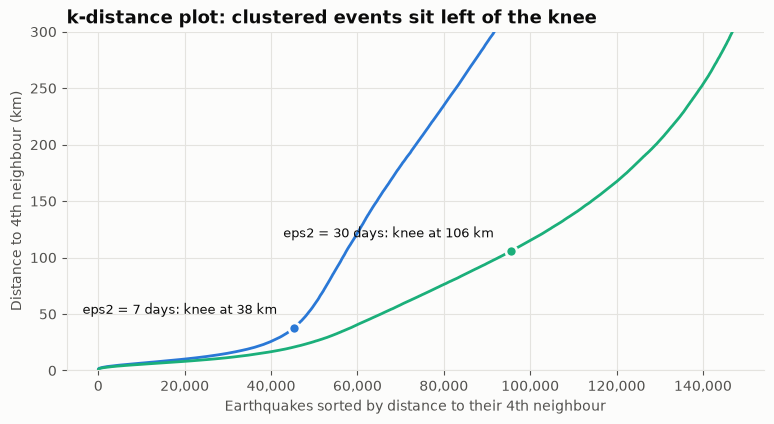

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for (eps2, y), color in zip(kdist.items(), (BLUE, AQUA)):
    ax.plot(np.arange(len(y)), y, color=color, lw=2)
    k = kd_table.loc[kd_table["eps2_days"] == eps2, "knee_km"].iloc[0]
    xk = np.searchsorted(y, k)
    ax.plot(xk, k, "o", ms=8, color=color, mec=SURFACE, mew=2)
    ax.annotate(f"eps2 = {eps2} days: knee at {k:.0f} km", (xk, k), xytext=(-12, 10),
                textcoords="offset points", ha="right", fontsize=9.5, color=INK)
ax.xaxis.set_major_formatter(thousands)
ax.set_ylim(0, SEARCH_KM)
ax.set_xlabel(f"Earthquakes sorted by distance to their {K}th neighbour")
ax.set_ylabel(f"Distance to {K}th neighbour (km)")
ax.set_title("k-distance plot: clustered events sit left of the knee")
save_fig(fig, "step5_kdistance.png")
plt.show()

## 4. Parameter search

Every combination is scored on the known earthquakes from Step 4:

* **aftershock capture**: share of the M4.5+ earthquakes in the 30 days after
  the mainshock and within 300 km that land in the **same cluster** as the
  mainshock (mean over the known events);
* **longest cluster (days)**: an M4.5+ aftershock sequence fades within months.
  A cluster longer than a year means steady background activity along a plate
  boundary was chained into one cluster, which is not a sequence.

**Rule:** the highest mean capture among the settings whose longest cluster is
at most 365 days; ties go to fewer clusters lasting over 180 days, then to the
smaller `eps1` and `eps2`.

In [6]:
followers = {}
for _, k in known.iterrows():
    r = k["row"]
    f = np.where((days > days[r]) & (days <= days[r] + 30))[0]
    followers[k["label"]] = f[haversine_km(np.full(len(f), r), f) <= 300]

def capture(lab):
    out = {}
    for _, k in known.iterrows():
        r, f = k["row"], followers[k["label"]]
        out[k["label"]] = float(((lab[f] == lab[r]) & (lab[r] >= 0)).mean()) if len(f) else np.nan
    return out

GRID_EPS1, GRID_EPS2, GRID_MS = (25, 50, 100, 150), (3, 7, 14, 30), (5, 10)
rows, t0 = [], time.time()
for eps1 in GRID_EPS1:
    for eps2 in GRID_EPS2:
        for ms in GRID_MS:
            lab = st_dbscan(eps1, eps2, ms)
            cl = lab >= 0
            span = df.loc[cl, "time"].groupby(lab[cl]).agg(lambda s: (s.max() - s.min()).total_seconds() / 86400)
            cap = capture(lab)
            rows.append({"eps1_km": eps1, "eps2_days": eps2, "min_samples": ms,
                         "clusters": int(span.size), "noise_pct": round((~cl).mean() * 100, 1),
                         "largest_cluster": int(np.bincount(lab[cl]).max()),
                         "longest_days": round(float(span.max()), 1),
                         "clusters_over_180d": int((span > 180).sum()),
                         **{f"capture {k}": round(v, 2) for k, v in cap.items()},
                         "mean_capture": round(float(np.nanmean(list(cap.values()))), 3)})
search = pd.DataFrame(rows)
search.to_csv(RESULTS_DIR / "step5_param_search.csv", index=False)
print(f"{len(search)} settings in {time.time() - t0:.0f} s")

ok = search[search["longest_days"] <= 365]
best = ok.sort_values(["mean_capture", "clusters_over_180d", "eps1_km", "eps2_days"],
                      ascending=[False, True, True, True]).iloc[0]
EPS1, EPS2, MIN_SAMPLES = int(best["eps1_km"]), int(best["eps2_days"]), int(best["min_samples"])
fact("chosen eps1 (km)", EPS1)
fact("chosen eps2 (days)", EPS2)
fact("chosen min_samples", MIN_SAMPLES)
fact("settings tried", len(search))
fact("settings with a cluster longer than 365 days", int((search["longest_days"] > 365).sum()))
search.sort_values("mean_capture", ascending=False).head(10)

32 settings in 57 s
chosen eps1 (km): 100
chosen eps2 (days): 7
chosen min_samples: 5
settings tried: 32
settings with a cluster longer than 365 days: 13


,eps1_km,eps2_days,min_samples,clusters,noise_pct,largest_cluster,longest_days,clusters_over_180d,capture Sumatra 2004,capture Tohoku 2011,capture Turkey 2023,capture Myanmar 2025,capture Kamchatka 2025,mean_capture
28,150,14,5,5121,46.2,4561,1525.8,35,1.00,1.0,1.00,1.00,1.0,0.999
30,150,30,5,3686,31.1,19507,9378.2,192,1.00,1.0,1.00,1.00,1.0,0.999
31,150,30,10,1811,49.2,4643,1547.4,173,1.00,1.0,1.00,1.00,1.0,0.999
22,100,30,5,4513,42.3,4453,1612.6,244,1.00,1.0,0.98,1.00,1.0,0.996
29,150,14,10,1603,66.6,3748,650.7,13,1.00,1.0,0.98,1.00,1.0,0.996
26,150,7,5,4555,60.1,3616,488.1,3,1.00,1.0,0.98,1.00,1.0,0.996
20,100,14,5,4691,56.8,3679,711.2,10,0.99,1.0,0.98,1.00,1.0,0.994
18,100,7,5,3567,66.5,2980,273.6,3,0.98,1.0,0.91,0.82,1.0,0.941
23,100,30,10,1763,61.6,3943,890.4,75,1.00,1.0,0.98,0.68,1.0,0.931
21,100,14,10,1222,72.1,3357,457.1,6,0.99,1.0,0.98,0.68,1.0,0.929


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step5_param_search.png


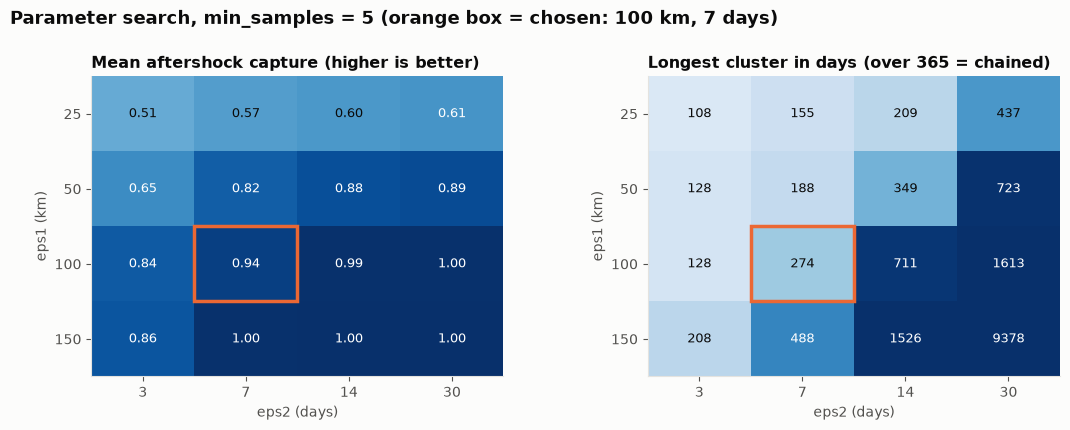

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9), gridspec_kw={"wspace": 0.35})
sub = search[search["min_samples"] == MIN_SAMPLES]
for ax, col, title, fmt, vmax in (
        (axes[0], "mean_capture", "Mean aftershock capture (higher is better)", "{:.2f}", 1),
        (axes[1], "longest_days", "Longest cluster in days (over 365 = chained)", "{:.0f}", 730)):
    m = sub.pivot(index="eps1_km", columns="eps2_days", values=col)
    im = ax.imshow(np.minimum(m.values, vmax), cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    for a in range(m.shape[0]):
        for b in range(m.shape[1]):
            v = m.values[a, b]
            ax.text(b, a, fmt.format(v), ha="center", va="center", fontsize=9.5,
                    color="white" if min(v, vmax) > vmax * 0.6 else INK)
    r, c = list(m.index).index(EPS1), list(m.columns).index(EPS2)
    ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, ec=ORANGE, lw=2.5))
    ax.set_xticks(range(m.shape[1]), m.columns); ax.set_yticks(range(m.shape[0]), m.index)
    ax.set_xlabel("eps2 (days)"); ax.set_ylabel("eps1 (km)")
    ax.set_title(title, fontsize=11.5); ax.grid(False)
fig.suptitle(f"Parameter search, min_samples = {MIN_SAMPLES} (orange box = chosen: "
             f"{EPS1} km, {EPS2} days)", x=0.06, ha="left", y=1.05, fontsize=13, fontweight="bold")
save_fig(fig, "step5_param_search.png")
plt.show()

## 5. Final clustering

Each cluster is described by its **mainshock** (largest earthquake). It is
called an *aftershock sequence* when at most 20% of its earthquakes come
before the mainshock, otherwise a *swarm* (activity that builds up without one
dominant first shock).

In [8]:
labels = st_dbscan(EPS1, EPS2, MIN_SAMPLES)
df["cluster"] = labels
df[["id", "cluster"]].to_csv(RESULTS_DIR / "step5_event_clusters.csv", index=False)

rows = []
for c, g in df[df["cluster"] >= 0].groupby("cluster"):
    m = g.loc[g["mag"].idxmax()]
    before = (g["time"] < m["time"]).mean()
    r = df.index.get_loc(m.name)
    extent = haversine_km(np.full(len(g), r), g.index.to_numpy()).max()
    rows.append({"cluster": c, "n_events": len(g), "start": g["time"].min(), "end": g["time"].max(),
                 "duration_days": round((g["time"].max() - g["time"].min()).total_seconds() / 86400, 1),
                 "mainshock_id": m["id"], "mainshock_time": m["time"], "mainshock_mag": m["mag"],
                 "mainshock_lat": m["latitude"], "mainshock_lon": m["longitude"], "region": m["region"],
                 "extent_km": round(float(extent), 1), "n_major": int(g["is_major"].sum()),
                 "pct_before_mainshock": round(before * 100, 1),
                 "type": "aftershock sequence" if before <= 0.2 else "swarm"})
clusters = pd.DataFrame(rows).sort_values("n_events", ascending=False).reset_index(drop=True)
clusters.insert(0, "rank", range(1, len(clusters) + 1))
clusters.to_csv(RESULTS_DIR / "clusters_summary.csv", index=False)

in_cl = df["cluster"] >= 0
fact("clusters", len(clusters))
fact("events in a cluster", int(in_cl.sum()))
fact("noise pct", round((~in_cl).mean() * 100, 1))
fact("aftershock sequences", int((clusters["type"] == "aftershock sequence").sum()))
fact("swarms", int((clusters["type"] == "swarm").sum()))
big = clusters[clusters["n_events"] >= 10]
fact("clusters with >= 10 events", len(big))
fact("aftershock sequences among clusters with >= 10 events", int((big["type"] == "aftershock sequence").sum()))
fact("swarms among clusters with >= 10 events", int((big["type"] == "swarm").sum()))
fact("median cluster size", int(clusters["n_events"].median()))
fact("median cluster duration (days)", float(clusters["duration_days"].median()))
fact("longest cluster (days)", float(clusters["duration_days"].max()))
fact("major earthquakes inside a cluster pct", round(df.loc[df["is_major"] == 1, "cluster"].ge(0).mean() * 100, 1))
clusters.head(10)

clusters: 3567
events in a cluster: 62875
noise pct: 66.5
aftershock sequences: 1991
swarms: 1576
clusters with >= 10 events: 1127
aftershock sequences among clusters with >= 10 events: 694
swarms among clusters with >= 10 events: 433
median cluster size: 7
median cluster duration (days): 8.1
longest cluster (days): 273.6
major earthquakes inside a cluster pct: 63.4


,rank,cluster,n_events,start,end,duration_days,mainshock_id,mainshock_time,mainshock_mag,mainshock_lat,mainshock_lon,region,extent_km,n_major,pct_before_mainshock,type
0,1,1253,2980,2011-03-09 02:45:20.330000+00:00,2011-10-10 02:45:57.860000+00:00,215.0,official20110311054624120_30,2011-03-11 05:46:24.120000+00:00,9.1,38.2970,142.3730,Japan,446.8,15,1.8,aftershock sequence
1,2,465,2326,2004-12-26 00:58:53.450000+00:00,2005-09-25 15:37:08.470000+00:00,273.6,official20041226005853450_30,2004-12-26 00:58:53.450000+00:00,9.1,3.2950,95.9820,2004 Sumatra - Andaman Islands Earthquake,1318.6,9,0.0,aftershock sequence
2,3,3374,1681,2025-07-20 06:02:51.862000+00:00,2025-12-09 10:54:36.947000+00:00,142.2,us6000qw60,2025-07-29 23:24:52.483000+00:00,8.8,52.4948,160.2395,Russia,625.1,9,9.4,aftershock sequence
3,4,2780,1130,2021-08-04 12:47:57.163000+00:00,2022-04-11 15:40:43.439000+00:00,250.1,us6000f53e,2021-08-12 18:35:17.231000+00:00,8.1,-58.3753,-25.2637,2021 South Sandwich Islands Earthquake,400.8,6,0.7,aftershock sequence
4,5,1156,993,2010-02-20 09:55:11.220000+00:00,2010-06-03 04:01:29+00:00,102.8,official20100227063411530_30,2010-02-27 06:34:11.530000+00:00,8.8,-36.1220,-72.8980,Chile,423.2,6,0.1,aftershock sequence
5,6,705,700,2006-11-08 08:22:31.480000+00:00,2007-02-13 10:30:46.080000+00:00,97.1,usp000exfn,2006-11-15 11:14:13.570000+00:00,8.3,46.5920,153.2660,2006 Kuril Islands Earthquake,283.7,3,2.0,aftershock sequence
6,7,2707,655,2021-02-22 23:49:23.260000+00:00,2021-05-20 00:32:48.482000+00:00,86.0,us7000dflf,2021-03-04 19:28:33.178000+00:00,8.1,-29.7228,-177.2794,New Zealand,302.2,3,2.9,aftershock sequence
7,8,1504,596,2013-01-27 12:41:11.280000+00:00,2013-04-14 08:35:38+00:00,76.8,usc000f1s0,2013-02-06 01:12:25.830000+00:00,8.0,-10.7990,165.1140,2013 Santa Cruz Islands Earthquake,262.3,7,9.4,aftershock sequence
8,9,3159,507,2023-12-02 14:37:04.454000+00:00,2024-01-22 07:54:03.284000+00:00,50.7,us7000lff4,2023-12-02 14:37:04.454000+00:00,7.6,8.5266,126.4161,Philippines,245.9,3,0.0,aftershock sequence
9,10,49,494,2000-10-17 20:45:02.680000+00:00,2001-01-10 17:39:19.430000+00:00,84.9,usp000a3qq,2000-11-16 04:54:56.740000+00:00,8.0,-3.9800,152.1690,2000 New Ireland Earthquake,425.9,8,7.1,aftershock sequence


## 6. Do the clusters find the known earthquakes?

In [9]:
chk = []
cap = capture(labels)
for _, k in known.iterrows():
    c = labels[k["row"]]
    row = clusters[clusters["cluster"] == c]
    chk.append({"event": k["label"], "mag": k["mag"], "in_cluster": c >= 0,
                "cluster_rank": int(row["rank"].iloc[0]) if c >= 0 else None,
                "cluster_events": int(row["n_events"].iloc[0]) if c >= 0 else 0,
                "cluster_days": float(row["duration_days"].iloc[0]) if c >= 0 else 0,
                "followers_30d_300km": len(followers[k["label"]]),
                "capture": round(cap[k["label"]], 2)})
check = pd.DataFrame(chk)
check.to_csv(RESULTS_DIR / "step5_known_events_check.csv", index=False)
fact("known events inside a cluster", f"{int(check['in_cluster'].sum())} of {len(check)}")
fact("mean aftershock capture of known events", round(check["capture"].mean(), 2))
top3 = clusters.head(3)
for _, r in top3.iterrows():
    fact(f"cluster rank {r['rank']}", f"{r['n_events']:,} events, {r['region']} M{r['mainshock_mag']:.1f} "
         f"{r['mainshock_time']:%Y-%m-%d}, {r['duration_days']:.0f} days, {r['type']}")
check

known events inside a cluster: 5 of 5
mean aftershock capture of known events: 0.94
cluster rank 1: 2,980 events, Japan M9.1 2011-03-11, 215 days, aftershock sequence
cluster rank 2: 2,326 events, 2004 Sumatra - Andaman Islands Earthquake M9.1 2004-12-26, 274 days, aftershock sequence
cluster rank 3: 1,681 events, Russia M8.8 2025-07-29, 142 days, aftershock sequence


,event,mag,in_cluster,cluster_rank,cluster_events,cluster_days,followers_30d_300km,capture
0,Sumatra 2004,9.1,True,2,2326,273.6,278,0.98
1,Tohoku 2011,9.1,True,1,2980,215.0,1910,1.00
2,Turkey 2023,7.8,True,49,154,18.8,169,0.91
3,Myanmar 2025,7.7,True,448,20,13.9,22,0.82
4,Kamchatka 2025,8.8,True,3,1681,142.2,834,1.00


## 7. Map of the clusters

saved C:\Users\user\Documents\assignment\earthquake_project\figures\step5_clusters_map.png


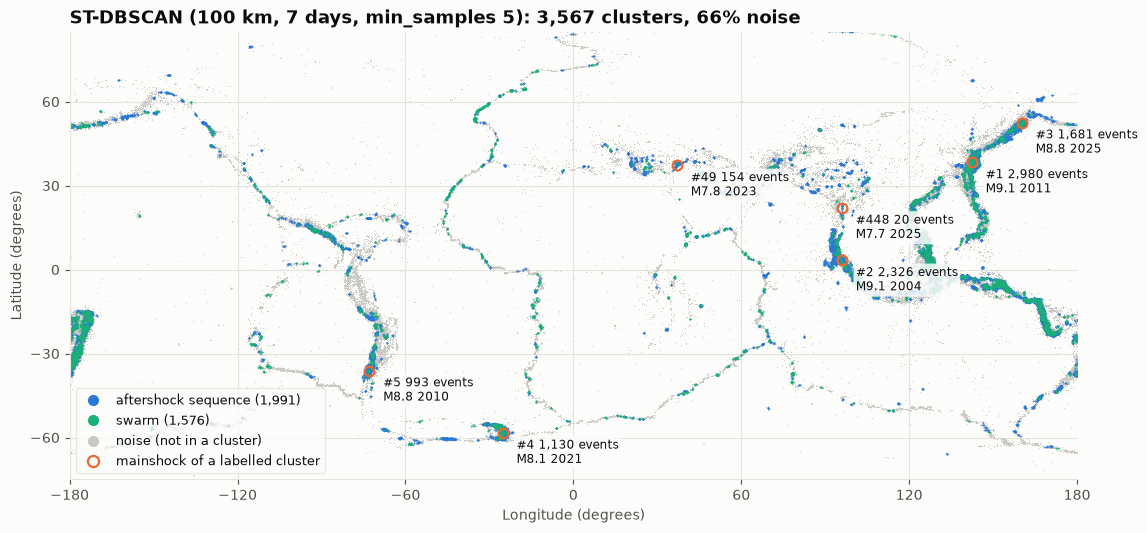

In [10]:
fig, ax = plt.subplots(figsize=(13, 6.6))
noise = df[~in_cl]
ax.scatter(noise["longitude"], noise["latitude"], s=0.4, c=NOISE, linewidths=0, rasterized=True)
type_color = {"aftershock sequence": BLUE, "swarm": AQUA}
ctype = df["cluster"].map(clusters.set_index("cluster")["type"])
for t, color in type_color.items():
    s = df[ctype == t]
    ax.scatter(s["longitude"], s["latitude"], s=1.6, c=color, alpha=0.7, linewidths=0, rasterized=True)
label_rows = pd.concat([clusters.head(5), clusters[clusters["cluster"].isin(labels[known["row"]])]]).drop_duplicates("cluster")
for _, r in label_rows.iterrows():
    ax.annotate(f"#{r['rank']} {r['n_events']:,} events\nM{r['mainshock_mag']:.1f} {r['mainshock_time']:%Y}",
                (r["mainshock_lon"], r["mainshock_lat"]), xytext=(10, -4), textcoords="offset points",
                fontsize=8.5, va="top", color=INK,
                bbox={"boxstyle": "round,pad=0.2", "fc": SURFACE, "ec": "none", "alpha": 0.85})
    ax.plot(r["mainshock_lon"], r["mainshock_lat"], "o", ms=7, mfc="none", mec=ORANGE, mew=1.6)
ax.set_xlim(-180, 180); ax.set_ylim(-75, 85); ax.set_aspect("equal")
ax.set_xticks(range(-180, 181, 60)); ax.set_yticks(range(-60, 81, 30))
ax.set_xlabel("Longitude (degrees)"); ax.set_ylabel("Latitude (degrees)")
ax.set_title(f"ST-DBSCAN ({EPS1} km, {EPS2} days, min_samples {MIN_SAMPLES}): "
             f"{len(clusters):,} clusters, {(~in_cl).mean() * 100:.0f}% noise")
from matplotlib.lines import Line2D
handles = [Line2D([], [], ls="", marker="o", ms=7, color=BLUE,
                  label=f"aftershock sequence ({(clusters['type'] == 'aftershock sequence').sum():,})"),
           Line2D([], [], ls="", marker="o", ms=7, color=AQUA, label=f"swarm ({(clusters['type'] == 'swarm').sum():,})"),
           Line2D([], [], ls="", marker="o", ms=7, color=NOISE, label="noise (not in a cluster)"),
           Line2D([], [], ls="", marker="o", ms=8, mfc="none", mec=ORANGE, mew=1.6, label="mainshock of a labelled cluster")]
ax.legend(handles=handles, loc="lower left", frameon=True, facecolor=SURFACE, edgecolor=GRID, fontsize=9)
save_fig(fig, "step5_clusters_map.png")
plt.show()

## 8. The three largest clusters over time

Cumulative number of earthquakes after the mainshock. A steep start that
flattens is the classic aftershock decay (Omori's law): most aftershocks come
in the first days.

cluster rank 1 pct of aftershocks in first 7 days: 47.6
cluster rank 2 pct of aftershocks in first 7 days: 23.5
cluster rank 3 pct of aftershocks in first 7 days: 52.1


saved C:\Users\user\Documents\assignment\earthquake_project\figures\step5_top_clusters.png


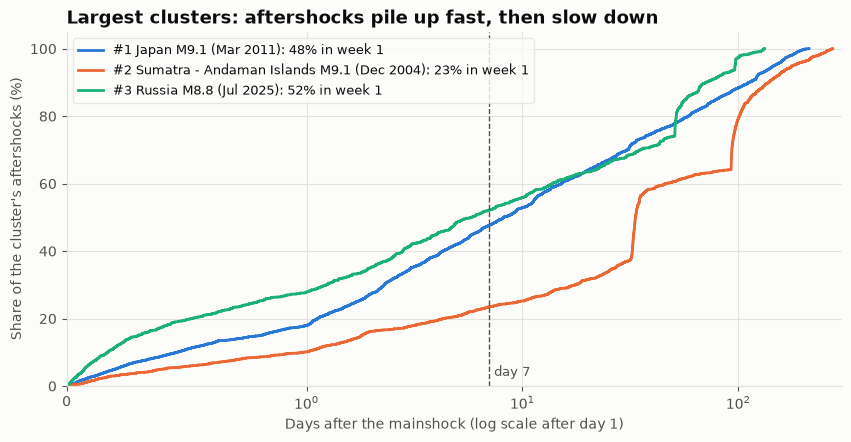

In [11]:
import re
short = lambda reg: re.sub(r"\s+earthquake(?: sequence)?$", "", re.sub(r"^\d{4}\s+", "", str(reg)), flags=re.I)
fig, ax = plt.subplots(figsize=(10, 4.6))
for (_, r), color, dy in zip(top3.iterrows(), (BLUE, ORANGE, AQUA), (0, 0, 0)):
    g = df[df["cluster"] == r["cluster"]]
    t = (g["time"] - r["mainshock_time"]).dt.total_seconds() / 86400
    t = np.sort(t[t >= 0].to_numpy())
    share = np.arange(1, len(t) + 1) / len(t) * 100
    week = (t <= 7).mean() * 100
    fact(f"cluster rank {r['rank']} pct of aftershocks in first 7 days", round(week, 1))
    ax.step(t, share, where="post", color=color, lw=2,
            label=f"#{r['rank']} {short(r['region'])} M{r['mainshock_mag']:.1f} ({r['mainshock_time']:%b %Y}): {week:.0f}% in week 1")
ax.legend(loc="upper left", frameon=True, facecolor=SURFACE, edgecolor=GRID, fontsize=9)
ax.axvline(7, color=MUTED, lw=1, ls="--")
ax.text(7.4, 3, "day 7", color=MUTED, fontsize=9)
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(0, top3["duration_days"].max() * 1.1)
ax.set_ylim(0, 105)
ax.set_xlabel("Days after the mainshock (log scale after day 1)")
ax.set_ylabel("Share of the cluster's aftershocks (%)")
ax.set_title("Largest clusters: aftershocks pile up fast, then slow down")
save_fig(fig, "step5_top_clusters.png")
plt.show()

## 9. Save the facts

In [12]:
pd.DataFrame(facts).to_csv(RESULTS_DIR / "step5_facts.csv", index=False)
print(f"saved {RESULTS_DIR / 'step5_facts.csv'} ({len(facts)} items)")

saved C:\Users\user\Documents\assignment\earthquake_project\results\step5_facts.csv (25 items)


## 10. Observations

1. **The method finds the great earthquakes without being told about them.** The
   seven largest clusters are all led by an M8.1+ mainshock; the top three are
   Tohoku 2011 (2,980 earthquakes), Sumatra 2004 (2,326) and Kamchatka 2025
   (1,681). All 5 known events from Step 4 are inside a cluster, and on average
   94% of their 30-day / 300 km aftershocks are in the same cluster.
2. **The parameters were chosen by a written rule, not by eye.** 32 settings were
   scored; 13 of them chain background activity into clusters longer than a
   year. The chosen 100 km / 7 days / min_samples 5 has the best aftershock
   capture among those that do not (longest cluster 274 days). The 7-day knee
   (38 km) is a lower bound: 25-50 km splits long ruptures such as Sumatra
   (about 1,300 km), which only 100 km keeps in one cluster.
3. **Two thirds of earthquakes are not part of a sequence.** 66.5% are noise
   (steady background activity); 62,875 earthquakes form 3,567 clusters with a
   median of 7 earthquakes over 8 days. Yet 63.4% of major earthquakes sit inside
   a cluster: big events come with company, which Step 7 can use as a feature.
4. **Aftershocks decay fast.** About half of the Tohoku and Kamchatka clusters
   happened in the first week (48% and 52%). Sumatra has only 23% in week one
   because its cluster also holds the 28 March 2005 Nias M8.6 earthquake about
   180 km away (the jump near day 92): one cluster can contain a triggered
   second great earthquake.
5. **Foreshocks are found too.** The Tohoku cluster starts on 9 March 2011, two
   days before the M9.1, with the M7.3 foreshock. Among clusters with at least 10
   earthquakes, 694 look like mainshock-aftershock sequences and 433 like swarms
   (more than 20% of the activity before the largest event).

**Limitations:** depth is not used (two earthquakes far apart in depth can be
neighbours); `eps1` and `eps2` are the same everywhere, although activity rates
differ by region; magnitudes are not used to scale the neighbourhood (a M9 has
a far larger aftershock zone than a M5).